# Hit-Prediction aus Audio-Features


## Exploration


In [17]:
import sqlite3 as sl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

con = sl.connect('spotify.sqlite')

with con:
    df_master = pd.read_sql_query("SELECT * FROM sqlite_master", con)
    print(f"Anzahl der Tabellen und Sichten: {len(df_master)} \n")
    print("Info über die Tabellen und Sichten:")
    df_master.info()

Anzahl der Tabellen und Sichten: 9 

Info über die Tabellen und Sichten:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      9 non-null      object
 1   name      9 non-null      object
 2   tbl_name  9 non-null      object
 3   rootpage  9 non-null      int64 
 4   sql       9 non-null      object
dtypes: int64(1), object(4)
memory usage: 488.0+ bytes


Da es sich um eine Spotify-Datenbank handelt, sind die wichtigsten Tabellen wahrscheinlich diejenigen, die Informationen über Songs, Alben, Künstler und Playlists enthalten. Um diese Tabellen zu identifizieren, können wir uns die Namen der Tabellen in der Datenbank ansehen. Es gibt die Spalte "name" und die Spalte "tbl_name", die beide die Namen der Tabellen enthalten. Es ist nicht ganz klar, was der Unterschied zwischen diesen beiden Spalten ist, daher sehen wir uns beide an.


In [18]:
print(f"Spalte name: \n{df_master.name} \n")
print(f"Spalte tbl_name: \n{df_master.tbl_name}")

Spalte name: 
0              albums
1             artists
2      audio_features
3              genres
4    r_albums_artists
5     r_albums_tracks
6      r_artist_genre
7      r_track_artist
8              tracks
Name: name, dtype: object 

Spalte tbl_name: 
0              albums
1             artists
2      audio_features
3              genres
4    r_albums_artists
5     r_albums_tracks
6      r_artist_genre
7      r_track_artist
8              tracks
Name: tbl_name, dtype: object


Die Spalte "name" und die Spalte "tbl_name" scheinen in diesem Fall identisch zu sein. Wir können also eine der beiden Spalten verwenden, um die Namen der Tabellen in der Datenbank zu erhalten. Wir filtern das Dataframe, um nur die Einträge mit dem Typ "table" zu erhalten, da wir nur an den Tabellen interessiert sind.


In [19]:
df_tables = df_master[df_master['type'] == 'table']
print(f"Tabellen in der Datenbank: \n{df_tables[['name', 'tbl_name']]}")

Tabellen in der Datenbank: 
               name          tbl_name
0            albums            albums
1           artists           artists
2    audio_features    audio_features
3            genres            genres
4  r_albums_artists  r_albums_artists
5   r_albums_tracks   r_albums_tracks
6    r_artist_genre    r_artist_genre
7    r_track_artist    r_track_artist
8            tracks            tracks


Fangen wir damit an, die Tabelle "tracks" anzusehen, da sie wahrscheinlich Informationen über die Songs enthält.


In [20]:
con.text_factory = lambda b: b.decode(errors='ignore')


def run_sql(query: str) -> pd.DataFrame:
    """Hilfsfunktion fuer kompakte SQL-Auswertungen."""
    return pd.read_sql_query(query, con)



df_tracks = run_sql("""
SELECT *
FROM tracks
""")

print("Info ueber Stichprobe der Tabelle 'tracks':")
df_tracks.info()
print()

print("Deskriptive Statistik:")
print(df_tracks.describe(include='all'))
print()

print("Erste 5 Eintraege:")
print(df_tracks.head())


Info ueber Stichprobe der Tabelle 'tracks' (200k Zeilen):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8741672 entries, 0 to 8741671
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                object 
 1   disc_number       int64  
 2   duration          int64  
 3   explicit          int64  
 4   audio_feature_id  object 
 5   name              object 
 6   preview_url       object 
 7   track_number      int64  
 8   popularity        int64  
 9   is_playable       float64
dtypes: float64(1), int64(5), object(4)
memory usage: 666.9+ MB

Deskriptive Statistik (Stichprobe):
                            id    disc_number        duration       explicit  \
count                  8741672 8,741,672.0000  8,741,672.0000 8,741,672.0000   
unique                 8741672            NaN             NaN            NaN   
top     1dizvxctg9dHEyaYTFufVi            NaN             NaN            NaN   
freq                         1      

### Datenqualität: Fehlende Werte, Duplikate, Wertebereiche


In [20]:
df_tracks_quality = run_sql("""
SELECT
    COUNT(*) AS n,
    SUM(CASE WHEN id IS NULL OR TRIM(id) = '' THEN 1 ELSE 0 END) AS id_missing,
    SUM(CASE WHEN audio_feature_id IS NULL OR TRIM(audio_feature_id) = '' THEN 1 ELSE 0 END) AS audio_feature_id_missing,
    SUM(CASE WHEN name IS NULL OR TRIM(name) = '' THEN 1 ELSE 0 END) AS name_missing,
    SUM(CASE WHEN duration IS NULL THEN 1 ELSE 0 END) AS duration_missing,
    SUM(CASE WHEN popularity IS NULL THEN 1 ELSE 0 END) AS popularity_missing,
    SUM(CASE WHEN explicit IS NULL THEN 1 ELSE 0 END) AS explicit_missing,
    SUM(CASE WHEN is_playable IS NULL THEN 1 ELSE 0 END) AS is_playable_missing,
    SUM(CASE WHEN preview_url IS NULL OR TRIM(preview_url) = '' THEN 1 ELSE 0 END) AS preview_url_missing,
    COUNT(*) - COUNT(DISTINCT id) AS duplicate_track_ids,
    COUNT(*) - COUNT(DISTINCT audio_feature_id) AS duplicate_audio_feature_ids_in_tracks,
    SUM(CASE WHEN popularity < 0 OR popularity > 100 THEN 1 ELSE 0 END) AS popularity_out_of_range,
    SUM(CASE WHEN explicit NOT IN (0, 1) AND explicit IS NOT NULL THEN 1 ELSE 0 END) AS explicit_invalid,
    SUM(CASE WHEN is_playable NOT IN (0, 1) AND is_playable IS NOT NULL THEN 1 ELSE 0 END) AS is_playable_invalid,
    SUM(CASE WHEN duration <= 0 THEN 1 ELSE 0 END) AS duration_non_positive
FROM tracks
""")
print("Qualitaetscheck tracks:")
print(df_tracks_quality.T)

Info ueber Stichprobe der Tabelle 'tracks' (200k Zeilen):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8741672 entries, 0 to 8741671
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                object 
 1   disc_number       int64  
 2   duration          int64  
 3   explicit          int64  
 4   audio_feature_id  object 
 5   name              object 
 6   preview_url       object 
 7   track_number      int64  
 8   popularity        int64  
 9   is_playable       float64
dtypes: float64(1), int64(5), object(4)
memory usage: 666.9+ MB

Deskriptive Statistik (Stichprobe):
                            id    disc_number        duration       explicit  \
count                  8741672 8,741,672.0000  8,741,672.0000 8,741,672.0000   
unique                 8741672            NaN             NaN            NaN   
top     1dizvxctg9dHEyaYTFufVi            NaN             NaN            NaN   
freq                         1      

## Leitplanken der Analyse
- **Feature-Raum (X):** nur `audio_features`
- **Targets (y):**
  - Klassifikation: `is_hit` wird spaeter datengetrieben aus der Popularity-Verteilung abgeleitet
  - Regression: `popularity` als kontinuierlicher Wert
- **Modelle:** Dummy-Baselines, klassische ML-Modelle, Feed Forward Neural Network (TensorFlow/Keras)
- **Wichtiger Guardrail:** kein Nutzerverhalten, keine Genre-Metadaten als Features

In [4]:
import sqlite3 as sl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style='whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

# Nimmt nur jede n-te DB-Zeile, um Laufzeit und RAM deutlich zu reduzieren.
SAMPLE_MODULO = 5
# Hoehere DPI vermeidet unscharfe Notebook-Grafiken.
PLOT_DPI = 160
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['savefig.dpi'] = PLOT_DPI

In [5]:
con = sl.connect('spotify.sqlite')
# Robust gegen kaputte Zeichen in Textfeldern der SQLite-Datei.
con.text_factory = lambda b: b.decode(errors='ignore')

def run_sql(query: str) -> pd.DataFrame:
    # Fuehrt SQL aus und liefert direkt ein DataFrame fuer Pandas-Analysen.
    return pd.read_sql_query(query, con)

feature_cols = [
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'speechiness',
    'valence',
    'loudness',
    'tempo',
    'key',
    'mode',
    'time_signature',
    'duration',
]

## 1) Exploration des Rohdatensatzes
Wir verbinden `tracks` und `audio_features`, um zunaechst den Rohbestand zu verstehen.

In [6]:
df_raw = run_sql(f"""
SELECT
    af.id AS audio_feature_id,
    t.id AS track_id,
    t.name AS track_name,
    t.popularity,
    af.acousticness,
    af.danceability,
    af.energy,
    af.instrumentalness,
    af.liveness,
    af.speechiness,
    af.valence,
    af.loudness,
    af.tempo,
    af.key,
    af.mode,
    af.time_signature,
    af.duration
FROM tracks t
JOIN audio_features af ON t.audio_feature_id = af.id
""")

print('--- SQL-Extraktion abgeschlossen ---')
print(f'Rohdatensatz: {df_raw.shape[0]:,} Zeilen x {df_raw.shape[1]} Spalten')
print('Spalten:', ', '.join(df_raw.columns.tolist()))
print('Beispielzeilen (erste 3):')
display(df_raw.head(3))

--- SQL-Extraktion abgeschlossen ---
Rohdatensatz: 8,741,110 Zeilen x 17 Spalten
Spalten: audio_feature_id, track_id, track_name, popularity, acousticness, danceability, energy, instrumentalness, liveness, speechiness, valence, loudness, tempo, key, mode, time_signature, duration
Beispielzeilen (erste 3):


,audio_feature_id,track_id,track_name,popularity,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,loudness,tempo,key,mode,time_signature,duration
0,1dizvxctg9dHEyaYTFufVi,1dizvxctg9dHEyaYTFufVi,Gz And Hustlas (feat. Nancy Fletcher),0,0.1640,0.6520,0.8140,0.0000,0.3600,0.3100,0.7880,-4.9010,91.8880,1,1,4,275893
1,2g8HN35AnVGIk7B8yMucww,2g8HN35AnVGIk7B8yMucww,Big Poppa - 2005 Remaster,77,0.4300,0.7800,0.5750,0.0000,0.1430,0.2730,0.7730,-7.2470,84.4920,9,0,4,252747
2,49pnyECzcMGCKAqxfTB4JZ,49pnyECzcMGCKAqxfTB4JZ,"You Were Born - Early Version Of ""One Of The T...",8,0.3310,0.6240,0.5640,0.2930,0.2560,0.0297,0.4310,-8.9280,111.9610,7,1,4,315080


## 2) Aufarbeitung und Qualitaetssicherung
Jetzt wird bereinigt: gueltige Wertebereiche, fehlende Werte und Duplikate werden transparent berichtet.

In [7]:

# Merkt sich die Rohmenge vor Cleaning fuer den Qualitaetsbericht.
rows_before = len(df_raw)
# Zaehlt doppelte Audio-Feature-IDs, um Mehrfachzuordnungen sichtbar zu machen.
duplicates = int(df_raw.duplicated(subset='audio_feature_id').sum())

# Datenqualitaets-Checks: gueltige Wertebereiche laut Spotify-Audio-Feature-Definition.
range_rules = {
    'popularity': lambda s: s.between(0, 100),
    'acousticness': lambda s: s.between(0, 1),
    'danceability': lambda s: s.between(0, 1),
    'energy': lambda s: s.between(0, 1),
    'instrumentalness': lambda s: s.between(0, 1),
    'liveness': lambda s: s.between(0, 1),
    'speechiness': lambda s: s.between(0, 1),
    'valence': lambda s: s.between(0, 1),
    # Loudness liegt typischerweise bei -60..0 dB; <= 5 deckt Ausreisser robust ab.
    'loudness': lambda s: s.between(-60, 5),
    'tempo': lambda s: s > 0,
    'duration': lambda s: s > 0,
    # key=-1 bedeutet laut Spotify "unknown" und wird explizit zugelassen.
    'key': lambda s: s.between(-1, 11),
    'mode': lambda s: s.isin([0, 1]),
    'time_signature': lambda s: s.between(3, 7),
}

invalid_counts = {
    col: int((~rule(df_raw[col]) & df_raw[col].notna()).sum())
    for col, rule in range_rules.items()
}
missing_counts = df_raw[feature_cols + ['popularity']].isna().sum().to_dict()

mask_valid = pd.Series(True, index=df_raw.index)
for col, rule in range_rules.items():
    mask_valid &= rule(df_raw[col])

df_clean = df_raw.loc[mask_valid].copy()

# Entfernt Duplikate/Nullwerte und erstellt eine saubere Modellbasis.
df_model = (
    df_clean
    .drop_duplicates(subset='audio_feature_id')
    .dropna(subset=feature_cols + ['popularity'])
    .reset_index(drop=True)
    .copy()
)

print('\n--- Nach Cleaning / Feature-Engineering ---')
print(f'Modelldatensatz: {len(df_model):,} Zeilen')
print('Binaeres Target ist noch nicht gesetzt (kommt in Abschnitt 3).')

overview = pd.DataFrame([
    {'Artefakt': 'Rows roh (SQL)', 'Anzahl': rows_before},
    {'Artefakt': 'Rows nach Range-Cleaning', 'Anzahl': len(df_clean)},
    {'Artefakt': 'Duplikate audio_feature_id', 'Anzahl': duplicates},
    {'Artefakt': 'Rows nach Dedup/Cleaning', 'Anzahl': len(df_model)},
    {'Artefakt': 'Sampling-Modulo', 'Anzahl': SAMPLE_MODULO},
])
display(overview)

quality_report = pd.DataFrame({
    'invalid_range': pd.Series(invalid_counts),
    'missing': pd.Series(missing_counts),
}).sort_values(['invalid_range', 'missing'], ascending=False)
print('\nTop Qualitätsprobleme (invalid/missing):')
display(quality_report.head(10))

# Bricht frueh ab, falls durch Filter unabsichtlich keine Daten mehr da sind.
assert not df_model.empty, 'Modelldatensatz ist leer. SQL-Filter pruefen.'


--- Nach Cleaning / Feature-Engineering ---
Modelldatensatz: 8,574,328 Zeilen
Binaeres Target ist noch nicht gesetzt (kommt in Abschnitt 3).


,Artefakt,Anzahl
0,Rows roh (SQL),8741110
1,Rows nach Range-Cleaning,8575395
2,Duplikate audio_feature_id,1067
3,Rows nach Dedup/Cleaning,8574328
4,Sampling-Modulo,5



Top Qualitätsprobleme (invalid/missing):


,invalid_range,missing
time_signature,165702,0
tempo,34764,0
loudness,14,0
acousticness,0,0
danceability,0,0
duration,0,0
energy,0,0
instrumentalness,0,0
key,0,0
liveness,0,0


## 3) Fragestellung formulieren: Was ist ein Hit?

In [10]:
import numpy as np

RANDOM_STATE = 42
TARGET_HIT_SHARE = 0.05

# Datengetriebene Hit-Definition: obere 5 % der Popularity-Verteilung.
HIT_THRESHOLD = int(np.ceil(df_model['popularity'].quantile(1 - TARGET_HIT_SHARE)))
df_model['is_hit'] = (df_model['popularity'] >= HIT_THRESHOLD).astype(int)

print(f'Gewaehlte Hit-Schwelle: popularity >= {HIT_THRESHOLD}')
print('Klassenhaeufigkeit is_hit (absolut):')
print(df_model['is_hit'].value_counts().sort_index())
print('Klassenanteile is_hit (relativ):')
print((df_model['is_hit'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + ' %')

assert df_model['is_hit'].nunique() == 2, 'Target is_hit hat nur eine Klasse. Schwelle/Filter pruefen.'

Gewaehlte Hit-Schwelle: popularity >= 30
Klassenhaeufigkeit is_hit (absolut):
is_hit
0    8141338
1     432990
Name: count, dtype: int64
Klassenanteile is_hit (relativ):
is_hit
0    94.95 %
1     5.05 %
Name: proportion, dtype: object


## 4) Deskriptive Statistik und Visualisierungen

,count,mean,std,min,25%,50%,75%,max
acousticness,"8,574,328.0000",0.4148,0.3745,0.0000,0.0320,0.3220,0.8040,0.9960
danceability,"8,574,328.0000",0.5370,0.1884,0.0000,0.4050,0.5520,0.6810,0.9970
energy,"8,574,328.0000",0.5515,0.2801,0.0000,0.3240,0.5760,0.7930,1.0000
instrumentalness,"8,574,328.0000",0.2541,0.3673,0.0000,0.0000,0.0017,0.6260,1.0000
liveness,"8,574,328.0000",0.2063,0.1812,0.0000,0.0963,0.1300,0.2640,1.0000
speechiness,"8,574,328.0000",0.0958,0.1383,0.0000,0.0360,0.0475,0.0835,0.9740
valence,"8,574,328.0000",0.4842,0.2785,0.0000,0.2450,0.4800,0.7170,1.0000
loudness,"8,574,328.0000",-10.6811,6.1712,-60.0000,-13.3580,-9.0640,-6.3320,4.9730
tempo,"8,574,328.0000",119.2854,30.1679,30.0020,95.8820,119.6950,137.8520,249.9870
key,"8,574,328.0000",5.2459,3.5424,0.0000,2.0000,5.0000,8.0000,11.0000


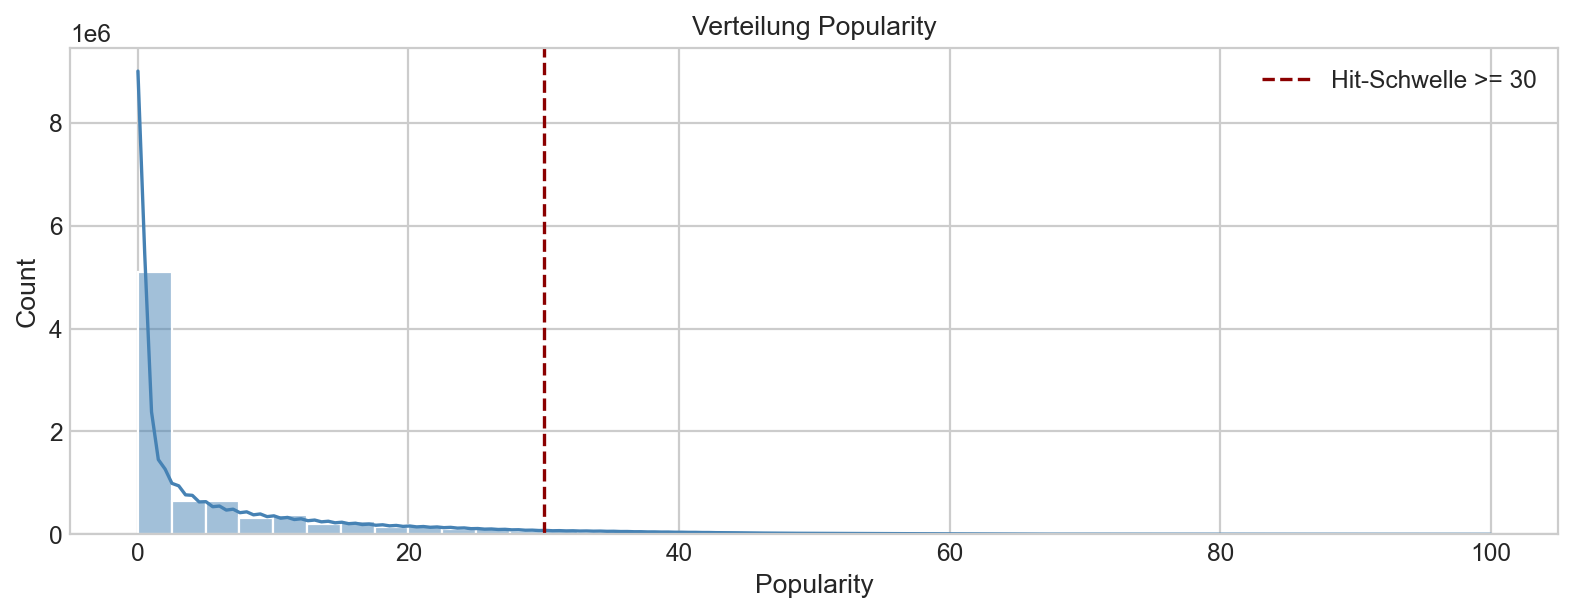

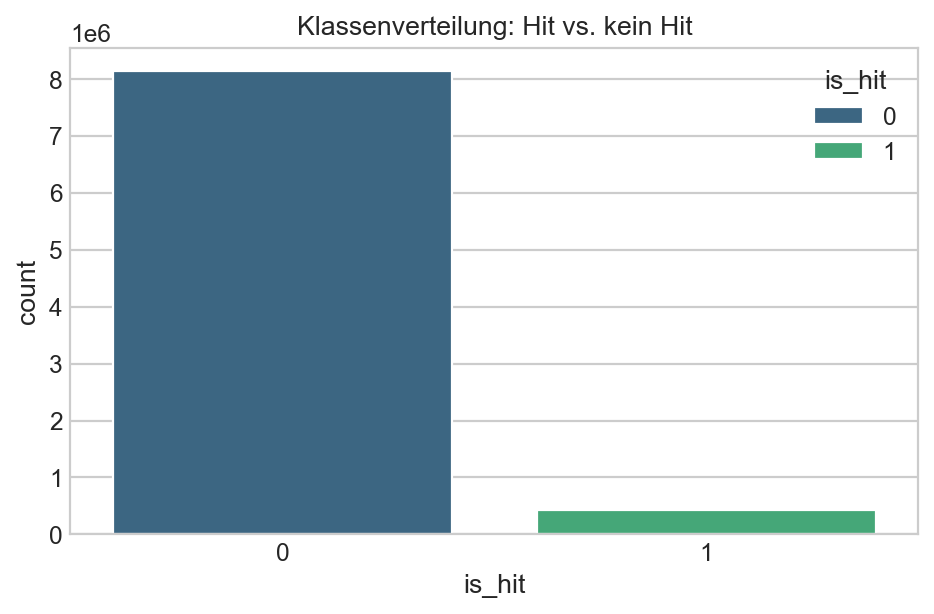

In [14]:
# Numerische Lage-/Streuungsmasse pro Feature + Zielvariable.
display(df_model[feature_cols + ['popularity']].describe().T)

plt.figure(figsize=(10, 4))
sns.histplot(df_model['popularity'], bins=40, kde=True, color='steelblue')
plt.axvline(HIT_THRESHOLD, color='darkred', linestyle='--', label=f'Hit-Schwelle >= {HIT_THRESHOLD}')
plt.title('Verteilung Popularity')
plt.xlabel('Popularity')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x='is_hit', palette='viridis', hue='is_hit')
plt.title('Klassenverteilung: Hit vs. kein Hit')
plt.xlabel('is_hit')
plt.tight_layout()
plt.show()

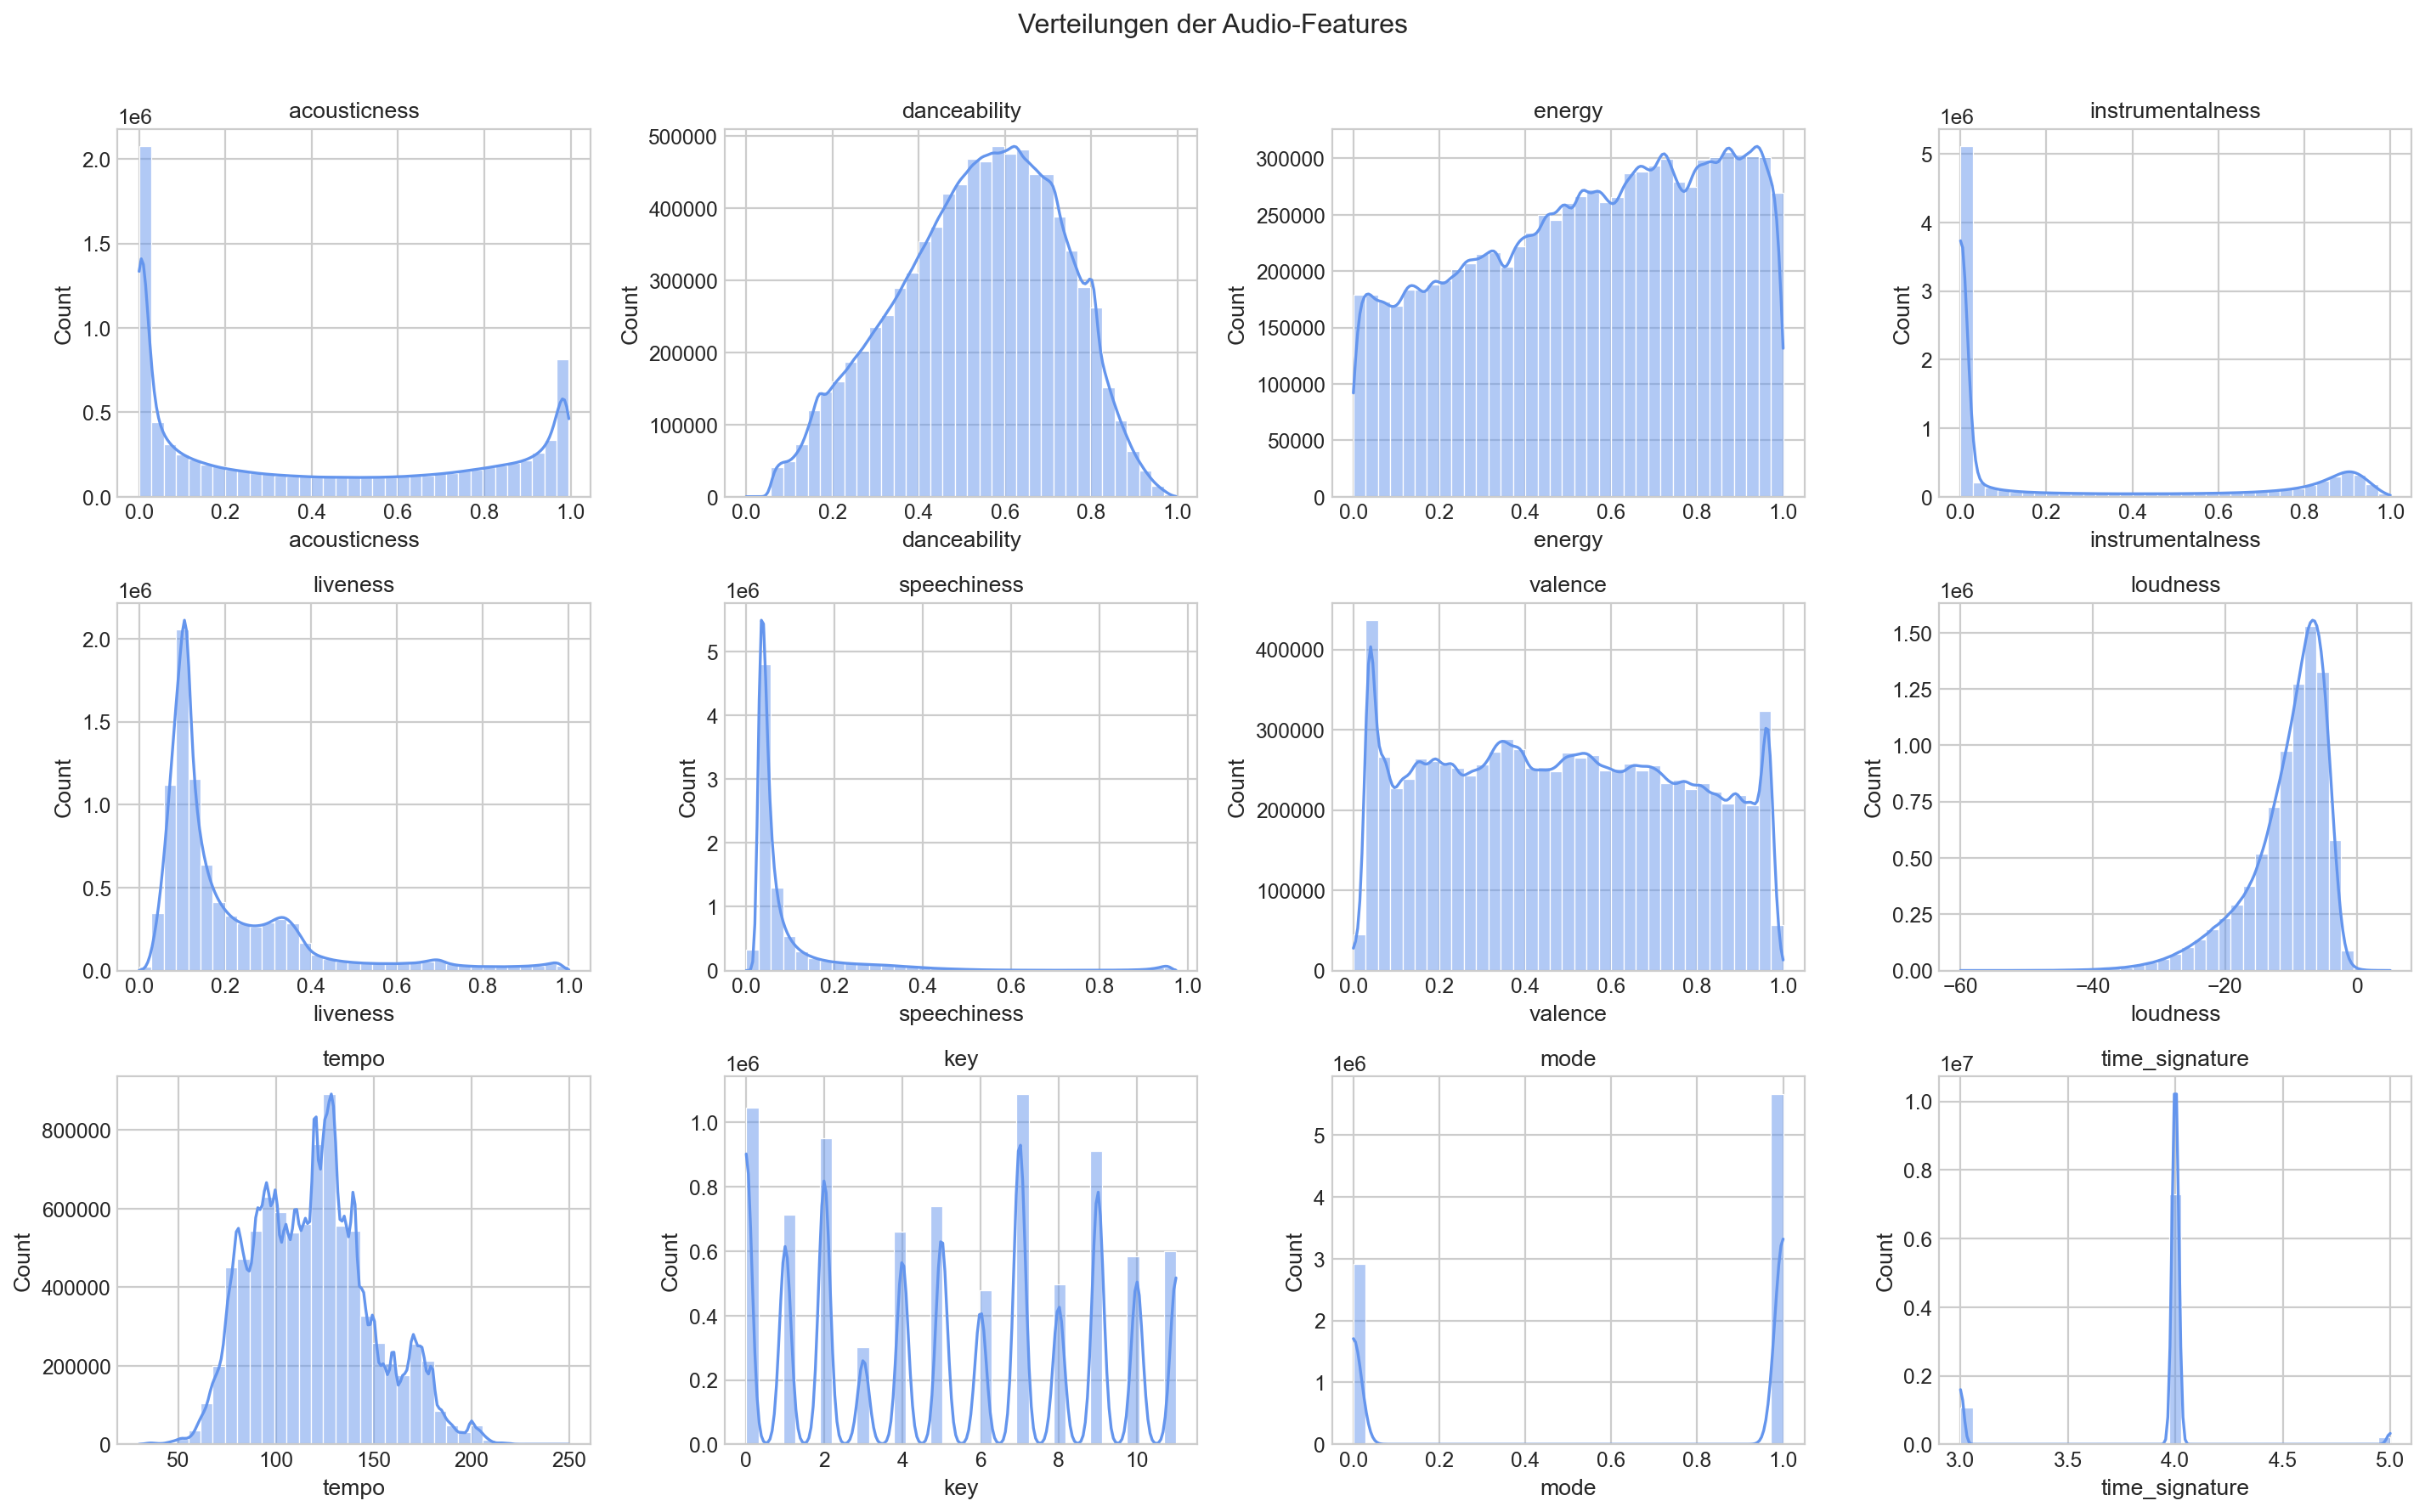

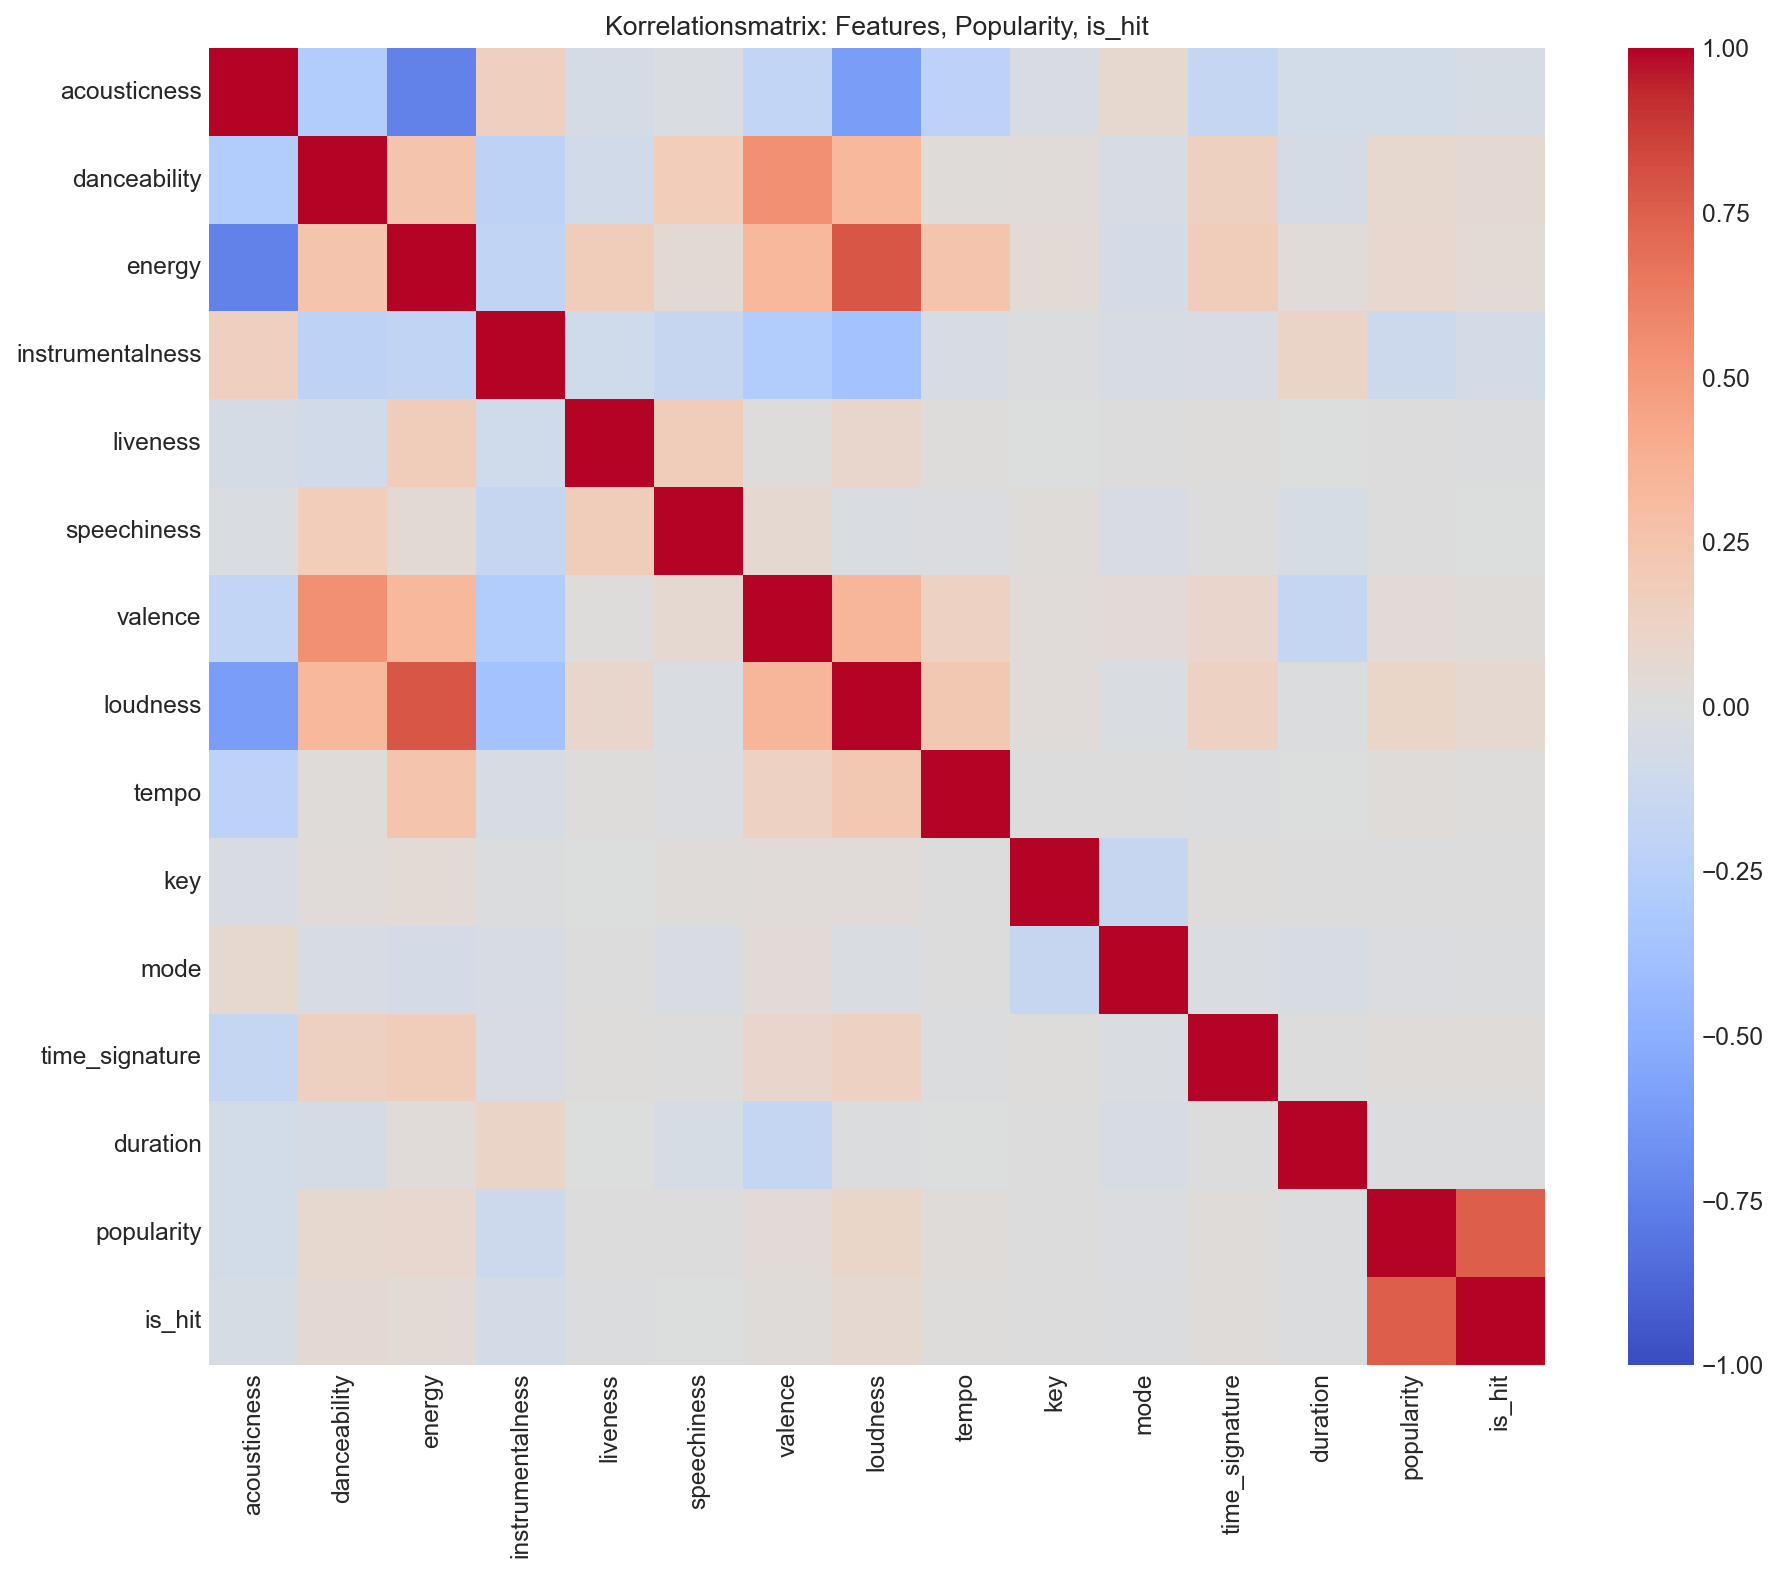

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
# Macht aus 2D-Array eine lineare Liste, damit for-loop einfacher ist.
axes = axes.flatten()

for ax, col in zip(axes, feature_cols[:12]):
    sns.histplot(df_model[col], bins=35, kde=True, ax=ax, color='cornflowerblue')
    ax.set_title(col)

plt.suptitle('Verteilungen der Audio-Features', y=1.01)
plt.tight_layout()
plt.show()

# Pearson-Korrelation

corr_cols = feature_cols + ['popularity', 'is_hit']
corr = df_model[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Korrelationsmatrix: Features, Popularity, is_hit')
plt.tight_layout()
plt.show()

## 5) Bearbeitung der Fragestellung: Modellierung
Wir splitten zuerst, dann lernen Skalierungs-Parameter nur auf dem Trainingsset.

In [ ]:
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

X = df_model[feature_cols].copy()
y_cls = df_model['is_hit'].copy()
y_reg = df_model['popularity'].copy()

# 70/30 Split; Stratify haelt Hit-Anteil stabil in Train/Temp.
X_train, X_temp, y_train_cls, y_temp_cls, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_cls,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)

# Temp wird 50/50 geteilt -> final 15% Validation, 15% Test.
X_val, X_test, y_val_cls, y_test_cls, y_val_reg, y_test_reg = train_test_split(
    X_temp,
    y_temp_cls,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp_cls,
)

split_info = pd.DataFrame([
    {'Split': 'Train', 'Rows': len(X_train), 'Hit-Quote': y_train_cls.mean()},
    {'Split': 'Validation', 'Rows': len(X_val), 'Hit-Quote': y_val_cls.mean()},
    {'Split': 'Test', 'Rows': len(X_test), 'Hit-Quote': y_test_cls.mean()},
])
display(split_info)

print('\n--- Split-Details ---')
print(f'Gesamt: {len(X):,} | Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print('Train-Klassen:', y_train_cls.value_counts().sort_index().to_dict())
print('Val-Klassen  :', y_val_cls.value_counts().sort_index().to_dict())
print('Test-Klassen :', y_test_cls.value_counts().sort_index().to_dict())

### 5.1) Klassifikation: Baselines und klassische ML-Modelle

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
cls_models = {
    'DummyMostFrequent': Pipeline([
        ('model', DummyClassifier(strategy='most_frequent'))
    ]),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    'RandomForestClassifier': Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    'HistGradientBoostingClassifier': Pipeline([
        ('model', HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ]),
}

def evaluate_classifier(model, X_eval: pd.DataFrame, y_true: pd.Series) -> dict:
    # Hartes Klassenlabel (0/1) fuer Accuracy/Precision/Recall/F1.
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        # Nutzt Wahrscheinlichkeiten fuer ROC-AUC (sauberer als harte Labels).
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        # Fallback, falls ein Modell keine predict_proba-Schnittstelle hat.
        y_proba = y_pred.astype(float)

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }

cls_rows = []
fitted_cls_models = {}

for name, model in cls_models.items():
    # Trainiert jedes Modell auf dem identischen Trainingssplit.
    print(f"\n[CLS] Starte Training: {name}")
    print(f"[CLS] Train-Daten: X={X_train.shape}, y={y_train_cls.shape}")
    model.fit(X_train, y_train_cls)
    fitted_cls_models[name] = model
    # Bewertet auf Validation (nicht auf Test), um Modellwahl fair zu halten.
    metrics_val = evaluate_classifier(model, X_val, y_val_cls)
    print('[CLS] Validation-Metriken:', {k: round(v, 4) for k, v in metrics_val.items()})
    cls_rows.append({'model': name, **metrics_val})

# Sortiert nach ROC-AUC, dann F1 als zweite Prioritaet.
df_cls_val = pd.DataFrame(cls_rows).sort_values(['roc_auc', 'f1'], ascending=False).reset_index(drop=True)
display(df_cls_val.round(4))

# Nimmt das Validation-beste Modell fuer den finalen Testcheck.
best_cls_name = df_cls_val.iloc[0]['model']
best_cls_model = fitted_cls_models[best_cls_name]
print(f'Bestes Klassifikationsmodell (Validation): {best_cls_name}')

In [ ]:
metrics_test = evaluate_classifier(best_cls_model, X_test, y_test_cls)
print('Testmetriken bestes Klassifikationsmodell:')
print(pd.Series(metrics_test).round(4))
print(f'Testdaten fuer Klassifikation: X={X_test.shape}, y={y_test_cls.shape}')

y_test_pred = best_cls_model.predict(X_test)
print('Vorhersageverteilung auf Test (0/1):', pd.Series(y_test_pred).value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_test_pred, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix ({best_cls_name})')

if hasattr(best_cls_model, 'predict_proba'):
    RocCurveDisplay.from_estimator(best_cls_model, X_test, y_test_cls, ax=axes[1])
    axes[1].set_title(f'ROC Curve ({best_cls_name})')
else:
    # Bei Modellen ohne Wahrscheinlichkeiten keine ROC-Kurve zeichnen.
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6) Interpretation der Ergebnisse

In [ ]:
# Welche Eigenschaften machen einen Hit aus? Permutation Importance zeigt, welche Features den größten Einfluss auf die Vorhersage haben, indem es die Performance misst, wenn ein Feature zufällig permutiert wird. Je größer der Performance-Verlust, desto wichtiger ist das Feature für das Modell.
from sklearn.inspection import permutation_importance

print("Berechne Feature Importances (das kann einen Moment dauern)...")

# Wir nehmen den HistGradientBoostingClassifier aus Ihrem Dictionary
best_model = fitted_cls_models['HistGradientBoostingClassifier']

# Permutation Importance berechnen (funktioniert für alle Modelle)
# Permutation Importance berechnen (jetzt mit der richtigen Metrik!)
result = permutation_importance(
    best_model,
    X_val,
    y_val_cls,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='roc_auc',         # <--- DAS IST DIE MAGISCHE NEUE ZEILE
    n_jobs=-1
)

# Der Rest Ihres Codes für das DataFrame und den Plot bleibt exakt gleich!

# Ergebnisse in ein DataFrame packen und sortieren
feature_names = X_val.columns
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance: Welche Eigenschaften machen einen Hit aus?')
plt.xlabel('Wichtigkeit (Einfluss auf die Vorhersage)')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wir erstellen ein DataFrame für die Visualisierung
# y_val_cls enthält Ihre 0 (Kein Hit) und 1 (Hit) Labels
df_vis = X_val.copy()
df_vis['Is_Hit'] = y_val_cls.values

# Wir wandeln die 0 und 1 in lesbare Texte um
df_vis['Kategorie'] = df_vis['Is_Hit'].map({0: 'Kein Hit', 1: 'Hit'})

# Figure mit 3 Subplots (nebeneinander) erstellen, Breite auf 18 erhöht
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Instrumentalness (Der wichtigste Faktor auf Platz 1!)
sns.boxplot(data=df_vis, x='Kategorie', y='instrumentalness', ax=axes[0], palette='Set2')
axes[0].set_title('Vergleich: Instrumentalität')
axes[0].set_ylabel('Instrumentalness (0=Gesang, 1=Kein Gesang)')

# Plot 2: Loudness
sns.boxplot(data=df_vis, x='Kategorie', y='loudness', ax=axes[1], palette='Set2')
axes[1].set_title('Vergleich: Lautstärke (Loudness)')
axes[1].set_ylabel('Loudness (dB)')

# Plot 3: Danceability
sns.boxplot(data=df_vis, x='Kategorie', y='danceability', ax=axes[2], palette='Set2')
axes[2].set_title('Vergleich: Tanzbarkeit (Danceability)')
axes[2].set_ylabel('Danceability (0 bis 1)')

plt.tight_layout()
plt.show()

## 7) Erweiterung: Feed Forward Neural Network (TensorFlow/Keras)

In [ ]:
import time

# Trainingsparameter fuer ein vollwertigeres FNN-Training.
NN_EPOCHS = 120
NN_BATCH_SIZE = 512

try:
    import tensorflow as tf
    TF_AVAILABLE = True
    tf.random.set_seed(RANDOM_STATE)
    TF_IMPORT_ERROR = None
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = repr(exc)

if not TF_AVAILABLE:
    print('TensorFlow nicht verfuegbar in dieser Umgebung - FNN wird uebersprungen.')
    print(globals().get('TF_IMPORT_ERROR'))
else:
    print('\n--- TensorFlow / Keras: Setup ---')
    print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
    print(f'Features pro Sample: {X_train.shape[1]}')
    print(f'Konfiguration: epochs={NN_EPOCHS}, batch_size={NN_BATCH_SIZE}, random_state={RANDOM_STATE}')

    scaler_tf = StandardScaler()
    # Fit nur auf Train verhindert Data Leakage in der Skalierung.
    X_train_tf = scaler_tf.fit_transform(X_train)
    X_val_tf = scaler_tf.transform(X_val)
    X_test_tf = scaler_tf.transform(X_test)

    # Raeumt alte Graphen auf, falls die Zelle mehrfach ausgefuehrt wird.
    tf.keras.backend.clear_session()

    # Fuer stabileres und reproduzierbares Verhalten als float32-Matrizen trainieren.
    X_train_tf = X_train_tf.astype(np.float32)
    X_val_tf = X_val_tf.astype(np.float32)
    X_test_tf = X_test_tf.astype(np.float32)
    y_train_tf = y_train_cls.to_numpy().astype(np.float32)
    y_val_tf = y_val_cls.to_numpy().astype(np.float32)

    # Klassenungleichgewicht abfedern, damit Recall/Precision fuer Hits nicht kippen.
    class_counts = np.bincount(y_train_cls.to_numpy(), minlength=2)
    n_total = class_counts.sum()
    class_weight = {
        0: n_total / (2 * max(class_counts[0], 1)),
        1: n_total / (2 * max(class_counts[1], 1)),
    }
    print('Class counts (Train):', {0: int(class_counts[0]), 1: int(class_counts[1])})
    print('Class weights:', {k: round(v, 4) for k, v in class_weight.items()})

    class EpochLogger(tf.keras.callbacks.Callback):
        # Kompakter Lernfortschritt pro Epoche fuer Nachvollziehbarkeit.
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            loss = logs.get('loss', float('nan'))
            val_loss = logs.get('val_loss', float('nan'))
            acc = logs.get('accuracy', float('nan'))
            val_acc = logs.get('val_accuracy', float('nan'))
            auc = logs.get('auc', float('nan'))
            val_auc = logs.get('val_auc', float('nan'))
            print(
                f"[Epoch {epoch + 1:03d}] "
                f"loss={loss:.4f} val_loss={val_loss:.4f} "
                f"acc={acc:.4f} val_acc={val_acc:.4f} "
                f"auc={auc:.4f} val_auc={val_auc:.4f}"
            )

    fnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
        tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    fnn.summary()

    fnn.compile(
        # Binary Crossentropy passt zu binaerer Hit-Klassifikation.
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )

    callbacks = [
        EpochLogger(),
        tf.keras.callbacks.EarlyStopping(
            # Stoppt frueh bei ausbleibender AUC-Verbesserung auf Validation.
            monitor='val_auc',
            mode='max',
            patience=15,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    start = time.perf_counter()
    history = fnn.fit(
        X_train_tf,
        y_train_tf,
        # Validation wird pro Epoche geloggt fuer Early Stopping.
        validation_data=(X_val_tf, y_val_tf),
        epochs=NN_EPOCHS,
        batch_size=NN_BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
        class_weight=class_weight,
    )
    train_seconds = time.perf_counter() - start

    y_prob_fnn = fnn.predict(X_test_tf, verbose=0).ravel()
    # Standard-Entscheidungsgrenze 0.5 fuer Klassenlabels.
    y_pred_fnn = (y_prob_fnn >= 0.5).astype(int)

    fnn_metrics = {
        'accuracy': accuracy_score(y_test_cls, y_pred_fnn),
        'precision': precision_score(y_test_cls, y_pred_fnn, zero_division=0),
        'recall': recall_score(y_test_cls, y_pred_fnn, zero_division=0),
        'f1': f1_score(y_test_cls, y_pred_fnn, zero_division=0),
        'roc_auc': roc_auc_score(y_test_cls, y_prob_fnn),
    }
    print('TensorFlow FNN - Testmetriken:')
    print(pd.Series(fnn_metrics).round(4))
    print(f'Epochen trainiert: {len(history.history["loss"])} / {NN_EPOCHS}')
    print(f'Trainingsdauer: {train_seconds:.1f} Sekunden')
    print('Test-Predictions >= 0.5 (Hits):', int((y_prob_fnn >= 0.5).sum()), 'von', len(y_prob_fnn))
    print('Wahrscheinlichkeitsbereich [min, max]:', f"[{y_prob_fnn.min():.4f}, {y_prob_fnn.max():.4f}]")

    best_epoch = int(np.argmax(history.history['val_auc']))
    print(
        'Beste Val-AUC:',
        f"{history.history['val_auc'][best_epoch]:.4f}",
        'in Epoche',
        best_epoch + 1,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title('FNN Loss')
    axes[0].legend()

    axes[1].plot(history.history['auc'], label='train_auc')
    axes[1].plot(history.history['val_auc'], label='val_auc')
    axes[1].set_title('FNN AUC')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 8) Fazit
- Die Struktur folgt jetzt bewusst dem wissenschaftlichen Ablauf: Exploration -> Aufarbeitung -> Fragestellung -> Bearbeitung -> Interpretation.
- Die Hit-Definition ist datengetrieben und damit besser begruendet als eine fixe, willkuerliche Grenze.
- Das beste Klassifikationsmodell wird sauber ueber Validation ausgewaehlt und erst danach auf dem Testset bewertet.
